### Pivot Table

The pivot table takes simple column-wise data as input and groups the entries into a two-dimensional table that summarizes data.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df=sns.load_dataset('tips')

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [15]:
df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_18888\884363850.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()


total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [16]:
df.pivot_table(index='sex',columns='smoker',values='total_bill')

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_18888\1243499625.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill')


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


### Aggregation functions
Use `aggfunc` (e.g., `sum`, `mean`) to aggregate values when building pivot tables.

In [ ]:
df.pivot_table(index='sex',columns='smoker',values='total_bill' ,aggfunc='sum')

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_18888\481992455.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill' ,aggfunc='sum')


smoker,Yes,No
sex,,
Male,1337.07,1919.75
Female,593.27,977.68


In [33]:
df.pivot_table(index='sex',columns='smoker',values=['size','total_bill',])

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_18888\3347491842.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values=['size','total_bill',])


size           total_bill           
smoker       Yes        No        Yes         No
sex                                             
Male    2.500000  2.711340  22.284500  19.791237
Female  2.242424  2.592593  17.977879  18.105185

In [41]:
df.pivot_table(index=['sex','smoker'],columns=['time','day'])

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_18888\345490666.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=['sex','smoker'],columns=['time','day'])


size                                                 tip  \
time              Lunch           Dinner                              Lunch   
day                Thur       Fri   Thur  Fri       Sat       Sun      Thur   
sex    smoker                                                                 
Male   Yes     2.300000  1.666667    NaN  2.4  2.629630  2.600000  3.058000   
       No      2.500000       NaN    NaN  2.0  2.656250  2.883721  2.941500   
Female Yes     2.428571  2.000000    NaN  2.0  2.200000  2.500000  2.990000   
       No      2.500000  3.000000    2.0  2.0  2.307692  3.071429  2.437083   

                                                      total_bill             \
time                Dinner                                 Lunch              
day             Fri   Thur    Fri       Sat       Sun       Thur        Fri   
sex    smoker                                                                 
Male   Yes     1.90    NaN  3.246  2.879259  3.521333  19.171000  11.386667   
       No       NaN    NaN  2.500  3.256563  3.115349  18.486500        NaN   
Female Yes     2.66    NaN  2.700  2.868667  3.500000  19.218571  13.260000   
       No      3.00    3.0  3.250  2.724615  3.329286  15.899167  15.980000   

                                                    
time          Dinner                                
day             Thur     Fri        Sat        Sun  
sex    smoker                                       
Male   Yes       NaN  25.892  21.837778  26.141333  
       No        NaN  17.475  19.929063  20.403256  
Female Yes       NaN  12.200  20.266667  16.540000  
       No      18.78  22.750  19.003846  20.824286

In [42]:
df.pivot_table(index='sex',columns='smoker',values='total_bill' ,aggfunc='sum',margins=True)

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_18888\3951543187.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill' ,aggfunc='sum',margins=True)


smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


### Pivot Plotting
Plot pivot tables directly using the DataFrame `plot()` method after reshaping.

In [50]:
df=pd.read_csv('Datasets/expense_data.csv')

In [46]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [55]:
df['Date']=pd.to_datetime(df['Date'])

In [58]:
df['month']=df['Date'].dt.month_name()

<Axes: xlabel='Category'>

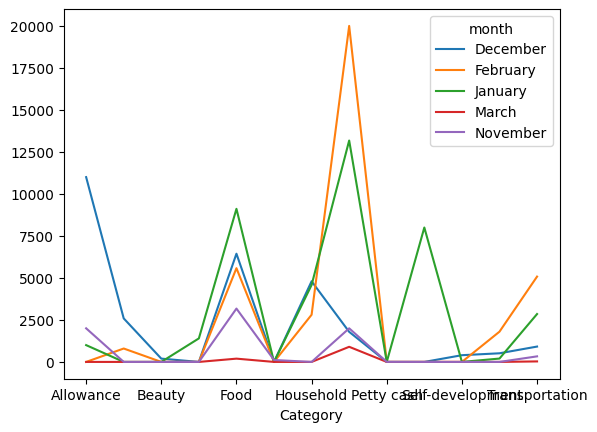

In [75]:
df.pivot_table(index='Category',columns='month',values='INR',aggfunc='sum',fill_value=0).plot()

<Axes: xlabel='month'>

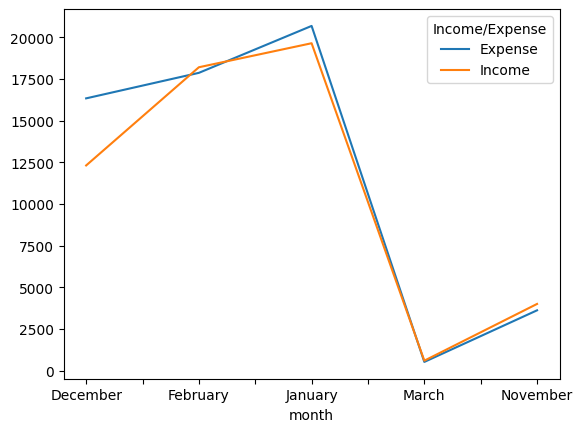

In [76]:
df.pivot_table(index='month',columns='Income/Expense',values='INR',aggfunc='sum').plot()

In [ ]:
# Functions used in this notebook (unique to Day 7 topic):
# pivot_table
# pivot
# crosstab
# groupby
# agg (aggregation functions)
# plot (DataFrame/Series plotting)
